<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_B%C3%81SICO/1_SELECT_FROM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<u>**CAMBIANDO Y PREPARANDO EL ENTORNO DE          TRABAJO A SQL**</u>

Lo primero que hice fue crear una nueva base de datos   
 * %load_ext sql es como un interruptor permite usar (%sql y %%sql)
 * %sql sirve para ejecutar una linea dentro de python
 * %%sql sirve para pasar de python a sql todas las celdas que vamos a usar, además es necesario usarlo en cada celda ya que google colab tiene celdas independientes y cada una usa python
 * %sql sqlite:///practica_inicial.db  esto es para cambiar la base de datos




In [48]:
#Nueva base de datos
%load_ext sql
%sql sqlite:///practica_inicial.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


<center>
<font size = '4'><u><b>CREATE TABLE / INSERT INTO</u></b></font>
</center>

Voy a crear el dataset que es provisorio para poder dar a conocer los comandos.

* <font color="violet">**CREATE TABLE**</font> crea el nombre de la tabla con sus multiples keys o columnas y cada columna esta definada por un type(en el caso de la columna id le pusimos que sea del type INT que es para numeros enteros)
* <font color="violet">**INSERT INTO**</font> llama al nombre de la tabla seguido por las multiples llaves o columnas( tabla(columna, columna, columna, columna) ó (tabla(keys, keys, keys, keys)) luego <font color="violet">**VALUES**</font> le pone valores a cada una de las columnas o keys

In [49]:

%%sql

DROP TABLE IF EXISTS viajeros;

CREATE TABLE viajeros(
    id INT,
    nombre VARCHAR(50),
    edad INT,
    pais VARCHAR(50)
);
INSERT INTO viajeros(id, nombre, edad, pais) VALUES
(1, 'Clara', 22, 'Venezuela'),
(2, 'Antonio', 30, 'Italia'),
(3, 'Emanuel', 32, 'Argentina'),
(4, 'Mia', 28, 'Uruguay' );


   sqlite:///ferreteria.db
 * sqlite:///practica_inicial.db
Done.
Done.
4 rows affected.


[]

<center>
<font size = '4'><u><b>Adelanto de SELECT y FROM</u></b></font>
</center>

* <font color="violet">**SELECT**</font> se usa para llamar a las columnas pero que pasa si tiene un asterisco '*', sucede que llama a todas las columnas que existan en la tabla en este caso las columnas de **practica_inicial.db** (id,	nombre,	edad,	pais) junto con todos sus datos
* <font color="violet">**FROM**</font> llama a la tabla que queramos analizar en este caso 'viajeros':

     FROM viajeros

     
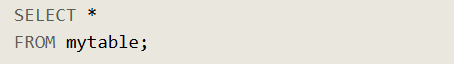



In [50]:
%%sql
SELECT * FROM viajeros;

   sqlite:///ferreteria.db
 * sqlite:///practica_inicial.db
Done.


id,nombre,edad,pais
1,Clara,22,Venezuela
2,Antonio,30,Italia
3,Emanuel,32,Argentina
4,Mia,28,Uruguay


<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [51]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset
# Tabla de Clientes (con su ubicación)
clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

# Tabla de Productos (con su categoría y precio)
# Usamos el nombre del producto como ID si no hay id_producto explícito,
# o simplemente agrupamos por nombre.
productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

# Tabla de Ventas (El corazón del negocio)
ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')
clientes.to_sql('clientes', conn, if_exists='replace', index=False)
productos.to_sql('productos', conn, if_exists='replace', index=False)
ventas.to_sql('ventas', conn, if_exists='replace', index=False)

# 4. Activar SQL
%load_ext sql
%sql sqlite:///ferreteria.db


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [52]:
#verificamos las columnas
print(df_original.columns)

Index(['id_venta', 'id_cliente', 'nombre_cliente', 'sucursal', 'provincia',
       'fecha_hora', 'producto', 'categoria', 'cantidad', 'precio_unitario',
       'total_venta', 'medio_pago', 'promo_producto', 'promo_pago',
       'otros_productos'],
      dtype='object')


<center>
<font size = '4' color =violet><u><b>SELECT/FROM<b/></u></font>
</center>

Utilizando las 3 tablas diferentes:productos, clientes y ventas


*   productos = Voy a utilizar las columnas ['producto', 'categoria']
*   clientes = Voy a utilizar las columnas ['nombre_cliente', 'provincia']
*   ventas = Voy a utilizar las columnas ['sucursal', 'medio_pago']



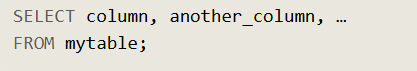





In [57]:
%%sql
SELECT nombre_cliente, provincia  -- # <--------columnas ['nombre_cliente', 'provincia']
FROM clientes   -- # <-------- tabla

LIMIT 25;


 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


nombre_cliente,provincia
Benjamin Perez Diaz,Buenos Aires
Amparo Paez Rodriguez,Mendoza
Martina Diaz Gimenez,Córdoba
Sr(a). Thiago Agustin Quiroga,Córdoba
Tomàs Victoria Aguero,Buenos Aires
Genaro Alma Fernandez,Córdoba
Santino Olivia Sosa Romero,Santa Fe
Sebastian Rojas Valdez,Córdoba
Nicolas Rivero Rios,Buenos Aires
Dante Federico Gonzalez Martinez,Córdoba


In [58]:
%%sql

SELECT producto, categoria --# <--------
FROM productos



LIMIT 25;

 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


producto,categoria
Caja de tornillos,Fijaciones
Taladro eléctrico,Herramientas eléctricas
Sierra circular,Herramientas eléctricas
Llave inglesa,Herramientas manuales
Sierra circular,Herramientas eléctricas
Destornillador,Herramientas manuales
Sierra circular,Herramientas eléctricas
Martillo,Herramientas manuales
Pintura látex 4L,Pinturas
Llave inglesa,Herramientas manuales


In [59]:
%%sql

SELECT sucursal, medio_pago
FROM ventas



LIMIT 20;

 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


sucursal,medio_pago
Sucursal Palermo,mercadopago
Sucursal Mendoza,mercadopago
Sucursal Córdoba,tarjeta_débito
Sucursal Córdoba,tarjeta_débito
Sucursal Palermo,mercadopago
Sucursal Córdoba,efectivo
Sucursal Rosario,efectivo
Sucursal Córdoba,efectivo
Sucursal Palermo,tarjeta_crédito
Sucursal Córdoba,transferencia


<center>
<font size = '5' color =violet><u><b>EJERCICIOS

1.  **Encuentra los productos existentes**





In [60]:
%%sql

SELECT producto
FROM productos



LIMIT 20;

 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


producto
Caja de tornillos
Taladro eléctrico
Sierra circular
Llave inglesa
Sierra circular
Destornillador
Sierra circular
Martillo
Pintura látex 4L
Llave inglesa


**2.Encuentra el nombre de los clientes**

In [61]:
%%sql
SELECT nombre_cliente
FROM clientes


LIMIT 20;

 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


nombre_cliente
Benjamin Perez Diaz
Amparo Paez Rodriguez
Martina Diaz Gimenez
Sr(a). Thiago Agustin Quiroga
Tomàs Victoria Aguero
Genaro Alma Fernandez
Santino Olivia Sosa Romero
Sebastian Rojas Valdez
Nicolas Rivero Rios
Dante Federico Gonzalez Martinez


**3.Encuentra el producto y la cantidad vendidas**

In [62]:
%%sql

SELECT producto, cantidad
FROM ventas


LIMIT 20;

 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


producto,cantidad
Caja de tornillos,2.0
Taladro eléctrico,1.0
Sierra circular,5.0
Llave inglesa,3.0
Sierra circular,5.0
Destornillador,1.0
Sierra circular,3.0
Martillo,4.0
Pintura látex 4L,4.0
Llave inglesa,5.0


4.Encuentra toda la información de ventas

In [63]:
%%sql

SELECT *
FROM ventas


LIMIT 20;

 * sqlite:///ferreteria.db
   sqlite:///practica_inicial.db
Done.


id_venta,fecha_hora,id_cliente,producto,cantidad,total_venta,sucursal,medio_pago
1,2025-06-29 12:36:14,2824,Caja de tornillos,2.0,23874.66,Sucursal Palermo,mercadopago
2,2025-02-27 08:47:28,2424,Taladro eléctrico,1.0,5591.07,Sucursal Mendoza,mercadopago
3,2024-09-26 19:31:40,7873,Sierra circular,5.0,73156.7,Sucursal Córdoba,tarjeta_débito
4,2025-02-26 10:24:10,5552,Llave inglesa,3.0,18024.9,Sucursal Córdoba,tarjeta_débito
5,2025-07-08 04:47:31,5333,Sierra circular,5.0,35582.4,Sucursal Palermo,mercadopago
6,2025-07-10 00:28:32,6925,Destornillador,1.0,33401.9,Sucursal Córdoba,efectivo
7,2024-12-28 05:42:28,7227,Sierra circular,3.0,26910.15,Sucursal Rosario,efectivo
8,2025-02-10 12:23:27,3803,Martillo,4.0,78373.28,Sucursal Córdoba,efectivo
9,2025-08-17 03:53:06,4752,Pintura látex 4L,4.0,56477.2,Sucursal Palermo,tarjeta_crédito
10,2025-01-06 21:29:09,5339,Llave inglesa,5.0,137049.45,Sucursal Córdoba,transferencia
